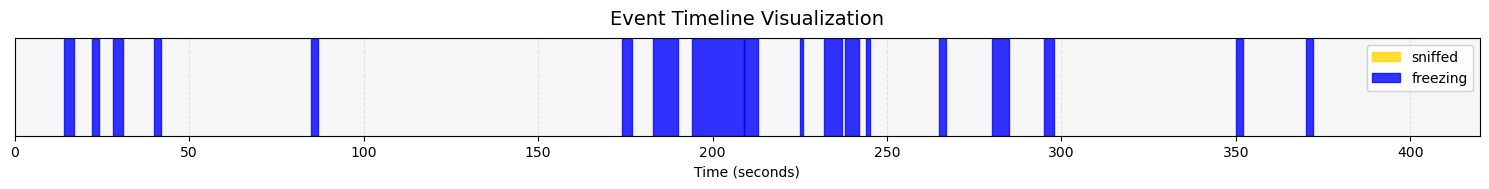

事件时间轴色柱图已生成并保存为 'event_timeline_visualization.png'


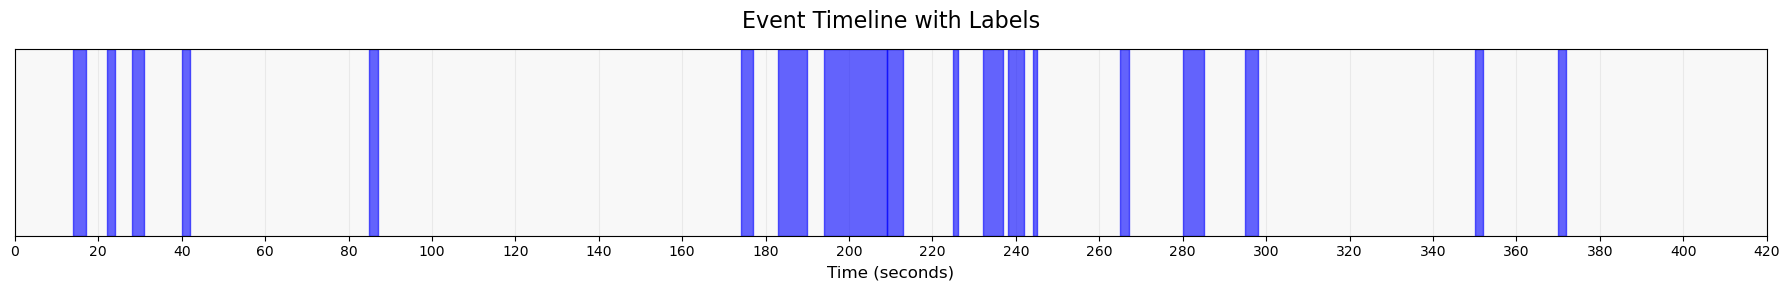

详细版事件时间轴图已生成并保存为 'event_timeline_detailed-1.png'


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# 读取事件数据
# 假设数据已经以DataFrame的形式存在
df = pd.read_excel('F:/AAA-RXC/PL8-4sessions/event4.xlsx')


# 定义事件到颜色的映射
event_colors = {
    #'sniff': 'green',
    'sniffed': 'gold',  # 使用gold代替yellow，更醒目
    'freezing': 'blue',
   # 'cs': 'red'
}

# 设置图形大小
fig, ax = plt.subplots(figsize=(15, 2))

# 设置坐标轴范围
ax.set_xlim(0, 420)
ax.set_ylim(0, 1)

# 隐藏y轴
ax.get_yaxis().set_visible(False)

# 设置x轴标签
ax.set_xlabel('Time (seconds)')

# 设置标题
ax.set_title('Event Timeline Visualization', fontsize=14, pad=10)

# 首先填充整个时间轴为浅灰色（背景）
ax.axvspan(0, 420, alpha=0.2, color='lightgray', zorder=1)

# 遍历每一行数据，绘制事件对应的色块
for _, row in df.iterrows():
    start = row['From Second']
    end = row['To Second']
    event = row['Event']
    
    # 只处理指定的事件类型
    if event in event_colors:
        color = event_colors[event]
        # 绘制色块
        ax.axvspan(start, end, alpha=0.8, color=color, zorder=2)

# 创建图例
legend_patches = []
for event, color in event_colors.items():
    patch = mpatches.Patch(color=color, alpha=0.8, label=event)   ##### 透明度 alpha
    legend_patches.append(patch)

# 添加图例
ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.0, 1.0), 
          frameon=True, framealpha=0.9)

# 添加网格线，便于查看时间点
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# 调整布局
plt.tight_layout()

# 保存图像
plt.savefig('event_timeline-PL8-4sessions-event4.png', dpi=300, bbox_inches='tight')   ################################################

# 显示图像
plt.show()

print("事件时间轴色柱图已生成并保存为 'event_timeline_visualization.png'")

# 可选：创建更详细的版本，包含事件标签
fig2, ax2 = plt.subplots(figsize=(18, 3))

# 设置坐标轴范围
ax2.set_xlim(0, 420)
ax2.set_ylim(0, 1)

# 隐藏y轴
ax2.get_yaxis().set_visible(False)

# 设置标题和轴标签
ax2.set_title('Event Timeline with Labels', fontsize=16, pad=15)
ax2.set_xlabel('Time (seconds)', fontsize=12)

# 填充背景为浅灰色
ax2.axvspan(0, 420, alpha=0.15, color='lightgray', zorder=1)

# 绘制事件色块并添加标签
for _, row in df.iterrows():
    start = row['From Second']
    end = row['To Second']
    event = row['Event']
    
    if event in event_colors:
        color = event_colors[event]
        # 绘制色块
        ax2.axvspan(start, end, alpha=0.6, color=color, zorder=2)
        
        # # 在色块中心添加事件标签
        # mid_point = (start + end) / 2
        # duration = end - start
        
        # # 只对持续时间较长的色块添加标签
        # if duration >= 5:
        #     ax2.text(mid_point, 0.5, event, 
        #             ha='center', va='center', 
        #             fontsize=9, color='white', 
        #             fontweight='bold',
        #             rotation=90 if duration < 10 else 0,
        #             zorder=3)

# 添加图例
# ax2.legend(handles=legend_patches, loc='upper right', 
#            bbox_to_anchor=(1.0, 1.0), ncol=2,
#            frameon=True, framealpha=0.9)

# 添加网格和刻度
ax2.grid(True, axis='x', alpha=0.2, linestyle='-')
ax2.set_xticks(range(0, 421, 20))  # 每30秒一个刻度

# 调整布局
plt.tight_layout()

# 保存详细版本
plt.savefig('PL8-4sessions-event4.png', dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

print("详细版事件时间轴图已生成并保存为 'event_timeline_detailed-1.png'")

## 对多只小鼠进行plot


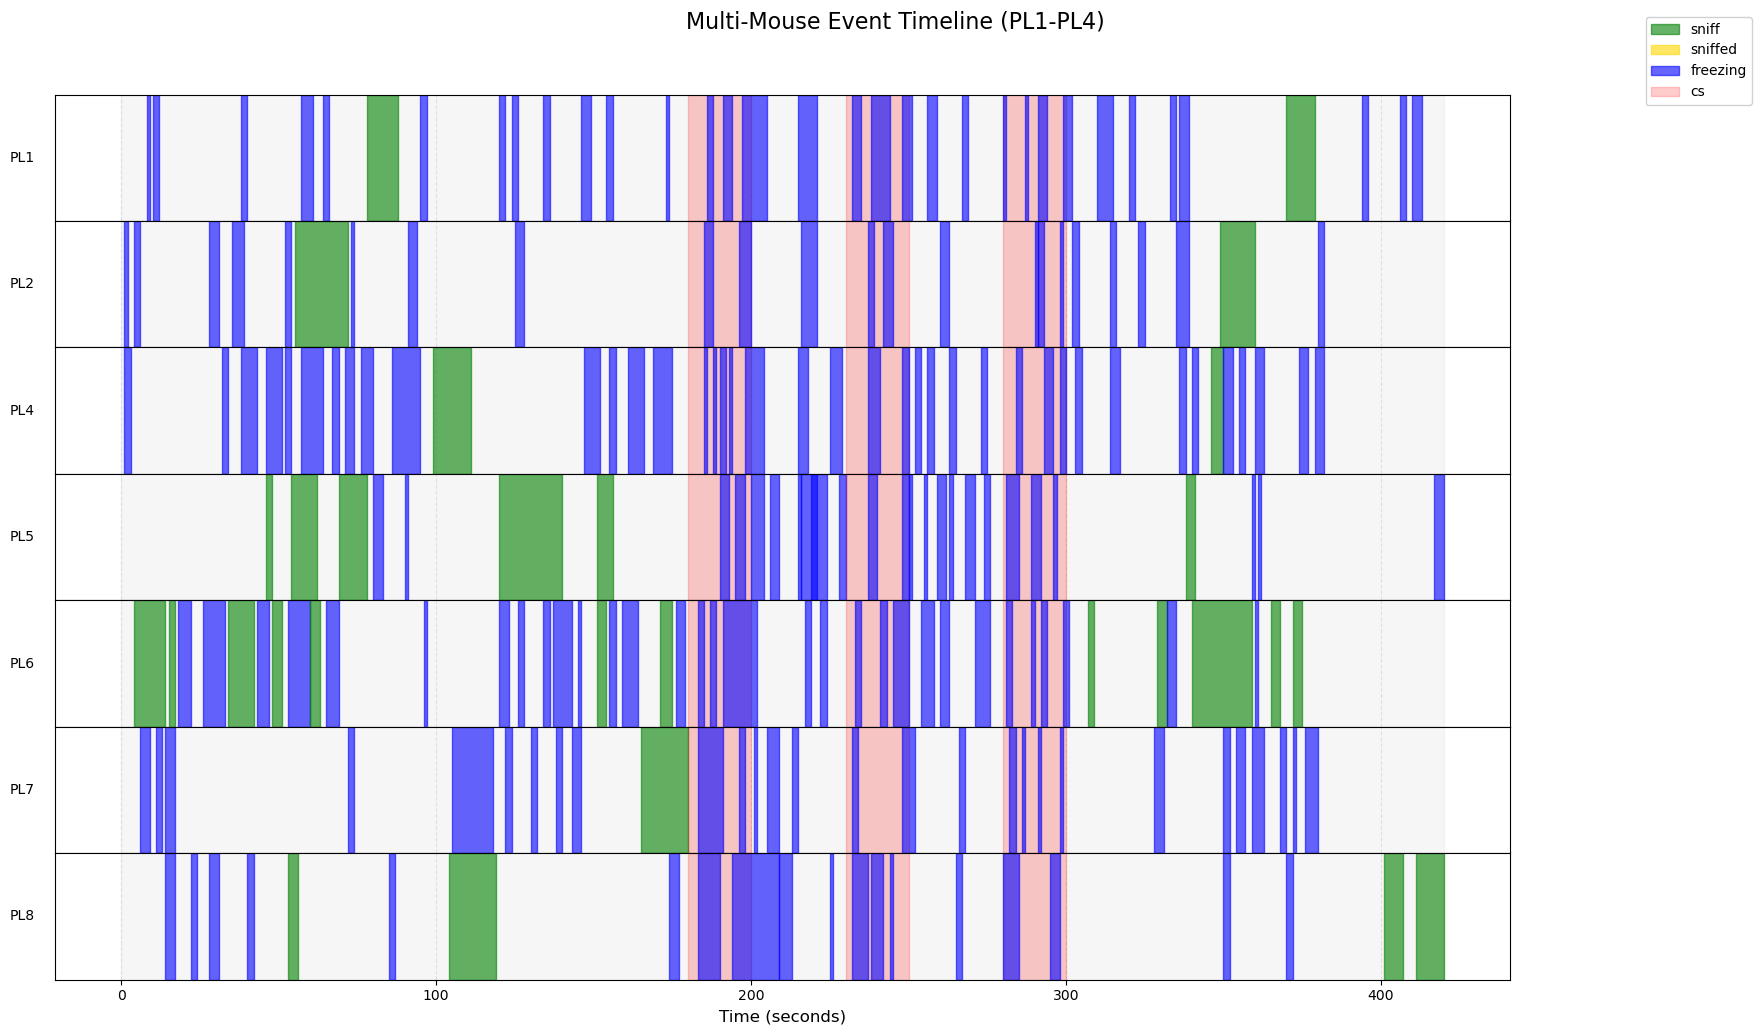

多小鼠事件时间轴图已保存为 'F:/AAA-RXC/Results\multi_mouse_event_timeline_PL1_PL4.png'
共处理 7 只小鼠，时间范围 0 ~ 420 秒。
小鼠名称: PL1, PL2, PL4, PL5, PL6, PL7, PL8


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ========== 配置参数 ==========
# 定义小鼠名称和对应的文件路径（根据实际信息填写）
mouse_files = {
    'PL1': 'F:/AAA-RXC/PL1-4sessions/event4.xlsx',
    'PL2': 'F:/AAA-RXC/PL2-4sessions/event4.xlsx',
    'PL4': 'F:/AAA-RXC/PL4-4sessions/event4.xlsx',
    'PL5': 'F:/AAA-RXC/PL5-4sessions/event4.xlsx',
    'PL6': 'F:/AAA-RXC/PL6-4sessions/event4.xlsx',
    'PL7': 'F:/AAA-RXC/PL7-4sessions/event4.xlsx',
    'PL8': 'F:/AAA-RXC/PL8-4sessions/event4.xlsx'
}

# 保存目录
save_dir = "F:/AAA-RXC/Results"
os.makedirs(save_dir, exist_ok=True)

# 事件颜色映射（固定）
event_colors = {
    'sniff': 'green',
    'sniffed': 'gold',
    'freezing': 'blue',
    'cs': 'red'
}

# 事件透明度设置：CS更透明，其他保持较高透明度
event_alpha = {
    'sniff': 0.6,
    'sniffed': 0.6,
    'freezing': 0.6,
    'cs': 0.2
}

# 图形尺寸：宽度固定，高度根据小鼠数量自动调整
base_height_per_mouse = 1.5  # 每只小鼠占的高度（英寸）
fig_width = 18                # 图宽（英寸）

# 时间轴范围（可根据数据自动计算，也可手动指定）
x_min = 0
x_max = 420  # 根据实际数据调整，也可设置为None让程序自动取最大值

# ========== 读取所有小鼠数据 ==========
df_list = []
mouse_names = sorted(mouse_files.keys())  # 保持顺序，也可自定义顺序
for mouse_name, file_path in mouse_files.items():
    # 读取Excel文件
    df_mouse = pd.read_excel(file_path)
    # 添加小鼠标识列，使用小鼠名称
    df_mouse['Mouse'] = mouse_name
    df_list.append(df_mouse)

# 合并所有数据
df = pd.concat(df_list, ignore_index=True)

# 获取小鼠ID列表（按名称排序，保证图形顺序）
mouse_ids = sorted(df['Mouse'].unique())  # 按字母顺序排序，也可用mouse_names列表直接控制顺序
n_mice = len(mouse_ids)

# 自动确定时间轴范围（可选，若x_max为None则自动计算）
if x_max is None:
    x_min = df['From Second'].min()
    x_max = df['To Second'].max()

# ========== 创建子图 ==========
fig, axes = plt.subplots(
    nrows=n_mice, ncols=1,
    figsize=(fig_width, base_height_per_mouse * n_mice),
    sharex=True,
    gridspec_kw={'hspace': 0}
)

# 如果只有一只小鼠，axes可能不是列表
if n_mice == 1:
    axes = [axes]

# ========== 绘制每只小鼠的事件 ==========
for idx, mouse in enumerate(mouse_ids):  # 按排序后的小鼠ID绘图
    ax = axes[idx]
    mouse_data = df[df['Mouse'] == mouse]

    # 设置y轴
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    # 用小鼠名称作为标签
    ax.set_ylabel(f'{mouse}', fontsize=10, rotation=0, labelpad=20, va='center')

    # 绘制背景
    ax.axvspan(x_min, x_max, alpha=0.2, color='lightgray', zorder=1)

    # 绘制事件色块
    for _, row in mouse_data.iterrows():
        start = row['From Second']
        end = row['To Second']
        event = row['Event']
        if event in event_colors:
            color = event_colors[event]
            alpha = event_alpha.get(event, 0.6)
            ax.axvspan(start, end, alpha=alpha, color=color, zorder=2)

            # 可选：为较长的色块添加事件标签（根据需要开启）
            # mid = (start + end) / 2
            # duration = end - start
            # if duration >= 5:
            #     ax.text(mid, 0.5, event, ha='center', va='center',
            #             fontsize=7, color='white', fontweight='bold', zorder=3)

    # 添加网格线
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# 设置公共x轴标签
axes[-1].set_xlabel('Time (seconds)', fontsize=12)

# ========== 创建图例 ==========
legend_patches = []
for event, color in event_colors.items():
    alpha = event_alpha.get(event, 0.6)
    patch = mpatches.Patch(color=color, alpha=alpha, label=event)
    legend_patches.append(patch)

# 图例放在图外右侧
fig.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(0.98, 0.98),
           frameon=True, framealpha=0.9, fontsize=10)

# 添加总标题
fig.suptitle('Multi-Mouse Event Timeline (PL1-PL4)', fontsize=16, y=0.98)

# 调整布局，为图例和标题留出空间
plt.tight_layout(rect=[0, 0, 0.85, 0.95])

# ========== 保存图片 ==========
save_path = os.path.join(save_dir, 'multi_mouse_event_timeline_PL1_PL4.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"多小鼠事件时间轴图已保存为 '{save_path}'")
print(f"共处理 {n_mice} 只小鼠，时间范围 {x_min} ~ {x_max} 秒。")
print("小鼠名称:", ", ".join(mouse_names))

## all mice without lines around

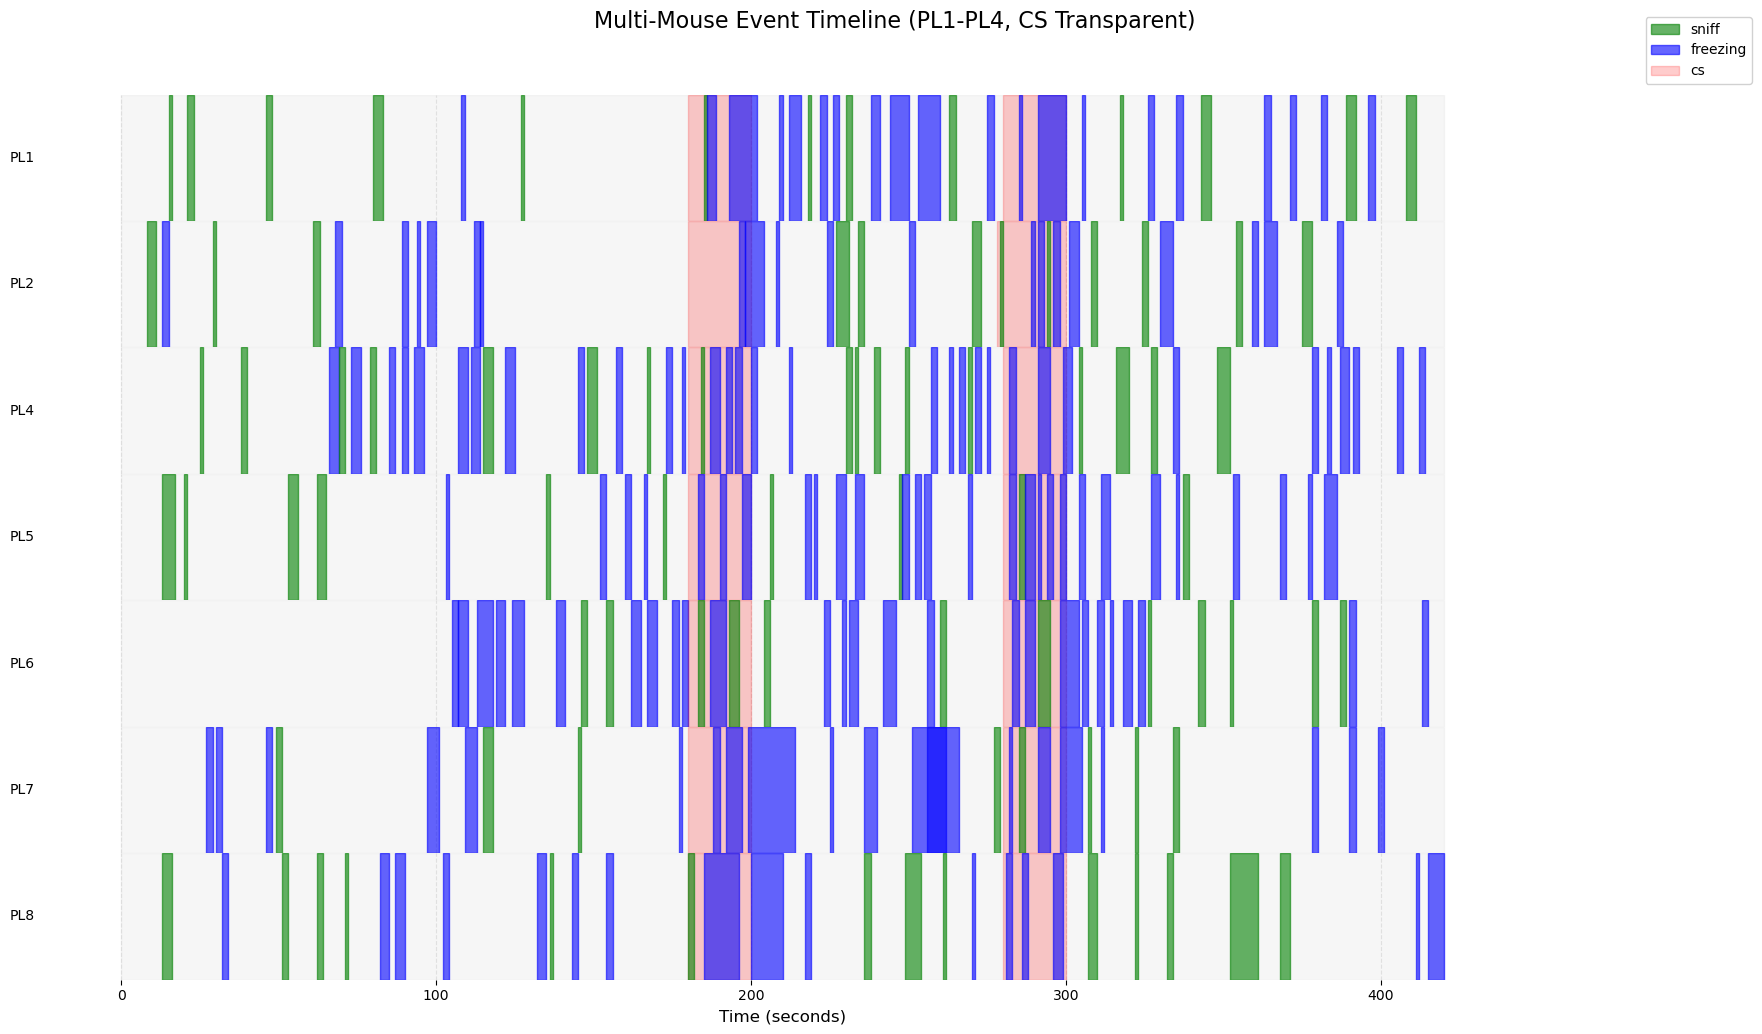

多小鼠事件时间轴图已保存为 'F:/AAA-RXC/Results\multi_mouse_event_timeline_PL1_PL4.png'
共处理 7 只小鼠：PL1, PL2, PL4, PL5, PL6, PL7, PL8
时间范围：0 ~ 420 秒


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ========== 配置参数 ==========
mouse_files = {
    'PL1': 'F:/AAA-RXC/PL1-4sessions/event3.xlsx',
    'PL2': 'F:/AAA-RXC/PL2-4sessions/event3.xlsx',
    'PL4': 'F:/AAA-RXC/PL4-4sessions/event3.xlsx',
    'PL5': 'F:/AAA-RXC/PL5-4sessions/event3.xlsx',
    'PL6': 'F:/AAA-RXC/PL6-4sessions/event3.xlsx',
    'PL7': 'F:/AAA-RXC/PL7-4sessions/event3.xlsx',
    'PL8': 'F:/AAA-RXC/PL8-4sessions/event3.xlsx'
}

save_dir = "F:/AAA-RXC/Results"
os.makedirs(save_dir, exist_ok=True)

event_colors = {
    'sniff': 'green',
    #'sniffed': 'gold',
    'freezing': 'blue',
    'cs': 'red'
}

event_alpha = {
    'sniff': 0.6,
    'sniffed': 0.6,
    'freezing': 0.6,
    'cs': 0.2
}

base_height_per_mouse = 1.5      # 每只小鼠占的高度（英寸）
fig_width = 18                    # 图宽（英寸）
x_min = 0
x_max = 420   # 或设为 None 自动计算

# ========== 读取数据 ==========
df_list = []
for mouse_name, file_path in mouse_files.items():
    df_mouse = pd.read_excel(file_path)
    df_mouse['Mouse'] = mouse_name
    df_list.append(df_mouse)

df = pd.concat(df_list, ignore_index=True)
mouse_ids = list(mouse_files.keys())
n_mice = len(mouse_ids)

if x_max is None:
    x_min = df['From Second'].min()
    x_max = df['To Second'].max()

# ========== 创建子图，间距设为0 ==========
fig, axes = plt.subplots(
    nrows=n_mice, ncols=1,
    figsize=(fig_width, base_height_per_mouse * n_mice),
    sharex=True,
    gridspec_kw={'hspace': 0}
)

if n_mice == 1:
    axes = [axes]

# ========== 绘制每只小鼠 ==========
for idx, mouse in enumerate(mouse_ids):
    ax = axes[idx]
    mouse_data = df[df['Mouse'] == mouse]

    # 设置y轴
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel(mouse, fontsize=10, rotation=0, labelpad=20, va='center')

    # 隐藏四个边框（去除黑色线条）
    for spine in ax.spines.values():
        spine.set_visible(False)

    # 绘制背景
    ax.axvspan(x_min, x_max, alpha=0.2, color='lightgray', zorder=1)

    # 绘制事件色块
    for _, row in mouse_data.iterrows():
        start = row['From Second']
        end = row['To Second']
        event = row['Event']
        if event in event_colors:
            color = event_colors[event]
            alpha = event_alpha.get(event, 0.6)
            ax.axvspan(start, end, alpha=alpha, color=color, zorder=2)

    # 添加网格线
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# 公共x轴标签（仅最后一个子图保留）
axes[-1].set_xlabel('Time (seconds)', fontsize=12)

# ========== 图例和标题 ==========
legend_patches = [
    mpatches.Patch(color=color, alpha=event_alpha.get(event, 0.6), label=event)
    for event, color in event_colors.items()
]

fig.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(0.98, 0.98),
           frameon=True, framealpha=0.9, fontsize=10)

fig.suptitle('Multi-Mouse Event Timeline (PL1-PL4, CS Transparent)', fontsize=16, y=0.98)

# 调整布局：左侧和右侧预留空间，底部为x轴标签留出空间，顶部为标题和图例留出空间
plt.tight_layout(rect=[0, 0, 0.85, 0.95])

# ========== 保存图片 ==========
save_path = os.path.join(save_dir, 'multi_mouse_event_timeline_PL1_PL4.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"多小鼠事件时间轴图已保存为 '{save_path}'")
print(f"共处理 {n_mice} 只小鼠：{', '.join(mouse_ids)}")
print(f"时间范围：{x_min} ~ {x_max} 秒")

图片将保存到: F:/AAA-RXC/Results


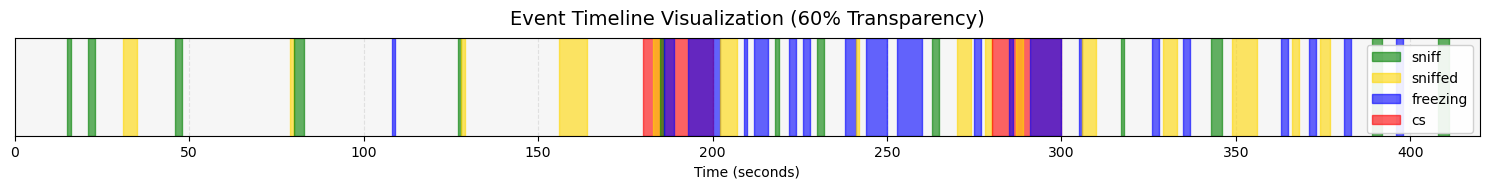

事件时间轴色柱图已生成并保存为 'F:/AAA-RXC/Results\event_timeline_visualization_60pct.png'


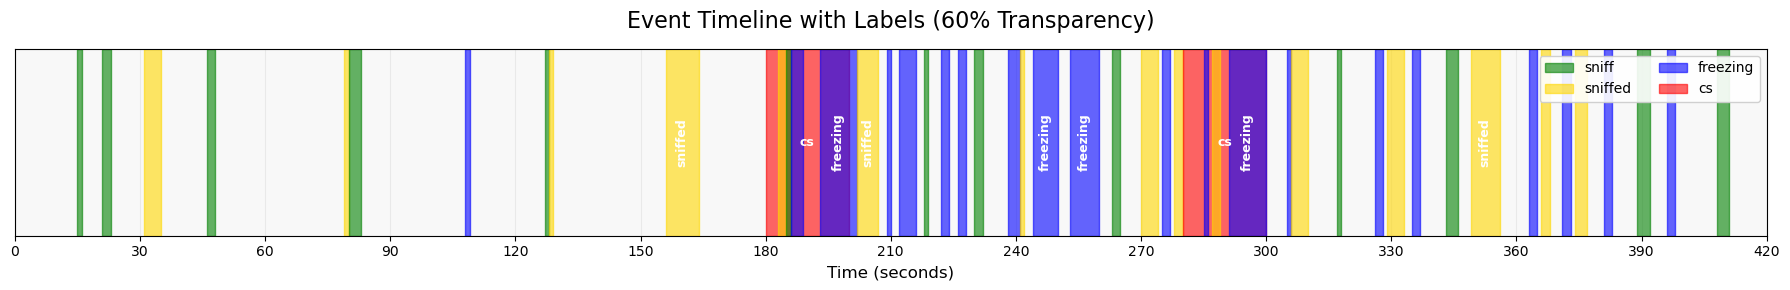

详细版事件时间轴图已生成并保存为 'F:/AAA-RXC/Results\event_timeline_detailed_60pct.png'


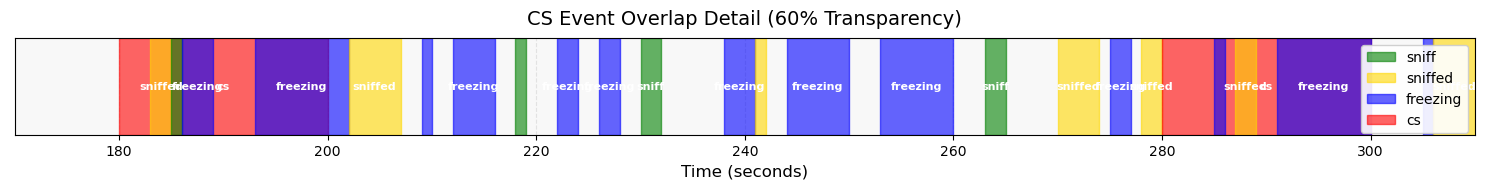

CS事件重叠细节图已生成并保存为 'F:/AAA-RXC/Results\cs_overlap_detail_60pct.png'

所有图片已成功保存到E盘目录: F:/AAA-RXC/Results
1. F:/AAA-RXC/Results\event_timeline_visualization_60pct.png
2. F:/AAA-RXC/Results\event_timeline_detailed_60pct.png
3. F:/AAA-RXC/Results\cs_overlap_detail_60pct.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# 读取事件数据

df = pd.read_excel('F:/AAA-RXC/PL1-4sessions/event3.xlsx')


# 定义事件到颜色的映射
event_colors = {
    'sniff': 'green',
    'sniffed': 'gold',
    'freezing': 'blue',
    'cs': 'red'
}

# 定义保存路径 - E盘
save_dir = "F:/AAA-RXC/Results"
os.makedirs(save_dir, exist_ok=True)  # 创建目录（如果不存在）

print(f"图片将保存到: {save_dir}")

# 设置图形大小
fig, ax = plt.subplots(figsize=(15, 2))

# 设置坐标轴范围
ax.set_xlim(0, 420)
ax.set_ylim(0, 1)

# 隐藏y轴
ax.get_yaxis().set_visible(False)

# 设置x轴标签
ax.set_xlabel('Time (seconds)')

# 设置标题
ax.set_title('Event Timeline Visualization (60% Transparency)', fontsize=14, pad=10)

# 首先填充整个时间轴为浅灰色（背景）
ax.axvspan(0, 420, alpha=0.2, color='lightgray', zorder=1)

# 遍历每一行数据，绘制事件对应的色块
for _, row in df.iterrows():
    start = row['From Second']
    end = row['To Second']
    event = row['Event']
    
    # 只处理指定的事件类型
    if event in event_colors:
        color = event_colors[event]
        # 绘制色块，透明度设置为60%（0.6）
        ax.axvspan(start, end, alpha=0.6, color=color, zorder=2)

# 创建图例
legend_patches = []
for event, color in event_colors.items():
    patch = mpatches.Patch(color=color, alpha=0.6, label=event)
    legend_patches.append(patch)

# 添加图例
ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.0, 1.0), 
          frameon=True, framealpha=0.9)

# 添加网格线，便于查看时间点
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# 调整布局
plt.tight_layout()

# 保存图像到E盘
save_path_1 = os.path.join(save_dir, 'event_timeline_visualization_60pct.png')
plt.savefig(save_path_1, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

print(f"事件时间轴色柱图已生成并保存为 '{save_path_1}'")

# 可选：创建更详细的版本，包含事件标签
fig2, ax2 = plt.subplots(figsize=(18, 3))

# 设置坐标轴范围
ax2.set_xlim(0, 420)
ax2.set_ylim(0, 1)

# 隐藏y轴
ax2.get_yaxis().set_visible(False)

# 设置标题和轴标签
ax2.set_title('Event Timeline with Labels (60% Transparency)', fontsize=16, pad=15)
ax2.set_xlabel('Time (seconds)', fontsize=12)

# 填充背景为浅灰色
ax2.axvspan(0, 420, alpha=0.15, color='lightgray', zorder=1)

# 绘制事件色块并添加标签
for _, row in df.iterrows():
    start = row['From Second']
    end = row['To Second']
    event = row['Event']
    
    if event in event_colors:
        color = event_colors[event]
        # 绘制色块，透明度设置为60%（0.6）
        ax2.axvspan(start, end, alpha=0.6, color=color, zorder=2)
        
        # 在色块中心添加事件标签
        mid_point = (start + end) / 2
        duration = end - start
        
        # 只对持续时间较长的色块添加标签
        if duration >= 5:
            ax2.text(mid_point, 0.5, event, 
                    ha='center', va='center', 
                    fontsize=9, color='white', 
                    fontweight='bold',
                    rotation=90 if duration < 10 else 0,
                    zorder=3)

# 添加图例
ax2.legend(handles=legend_patches, loc='upper right', 
           bbox_to_anchor=(1.0, 1.0), ncol=2,
           frameon=True, framealpha=0.9)

# 添加网格和刻度
ax2.grid(True, axis='x', alpha=0.2, linestyle='-')
ax2.set_xticks(range(0, 421, 30))  # 每30秒一个刻度

# 调整布局
plt.tight_layout()

# 保存详细版本到E盘
save_path_2 = os.path.join(save_dir, 'event_timeline_detailed_60pct.png')
plt.savefig(save_path_2, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

print(f"详细版事件时间轴图已生成并保存为 '{save_path_2}'")

# 特别展示cs与其他event重叠的区域
fig3, ax3 = plt.subplots(figsize=(15, 2))

# 设置坐标轴范围（重点展示cs事件发生的区域）
ax3.set_xlim(170, 310)  # 聚焦cs事件区域
ax3.set_ylim(0, 1)

# 隐藏y轴
ax3.get_yaxis().set_visible(False)

# 设置标题和轴标签
ax3.set_title('CS Event Overlap Detail (60% Transparency)', fontsize=14, pad=10)
ax3.set_xlabel('Time (seconds)', fontsize=12)

# 填充背景为浅灰色
ax3.axvspan(170, 310, alpha=0.15, color='lightgray', zorder=1)

# 绘制事件色块
for _, row in df.iterrows():
    start = row['From Second']
    end = row['To Second']
    event = row['Event']
    
    # 只绘制在选定时间范围内的事件
    if start < 310 and end > 170 and event in event_colors:
        color = event_colors[event]
        # 绘制色块，透明度设置为60%（0.6）
        ax3.axvspan(max(start, 170), min(end, 310), alpha=0.6, color=color, zorder=2)
        
        # 添加事件标签
        mid_point = (max(start, 170) + min(end, 310)) / 2
        duration = min(end, 310) - max(start, 170)
        
        if duration >= 2:
            ax3.text(mid_point, 0.5, event, 
                    ha='center', va='center', 
                    fontsize=8, color='white', 
                    fontweight='bold',
                    zorder=3)

# 添加图例
ax3.legend(handles=legend_patches, loc='upper right', 
           bbox_to_anchor=(1.0, 1.0),
           frameon=True, framealpha=0.9)

# 添加网格
ax3.grid(True, axis='x', alpha=0.3, linestyle='--')

# 调整布局
plt.tight_layout()

# 保存详细版本到E盘
save_path_3 = os.path.join(save_dir, 'cs_overlap_detail_60pct.png')
plt.savefig(save_path_3, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

print(f"CS事件重叠细节图已生成并保存为 '{save_path_3}'")

print(f"\n所有图片已成功保存到E盘目录: {save_dir}")
print(f"1. {save_path_1}")
print(f"2. {save_path_2}")
print(f"3. {save_path_3}")